### Projectinformatie
**Opleiding:** Toegepaste Wiskunde & Data Science  
**Vak:** Beroepsproject 3.4  
**Begeleider:** R. Nolet  
**Datum:** 20-03-2026  

| Teamleden                  | Studentnummer |
|----------------------|---------------|
| Murielle Tichelaar    | 500926485     |
| Nalini Bisessar       | 500874334     |
| Lushan Strack         | 500934278     |
| Dinand Voogt          | 500934202     |

# Beslisboom voor Churn voorspelling
We trainen een **Beslisboom** om churn bij klanten te voorspellen. 
Het doel is om te onderzoeken hoe goed een Beslisboom kan onderscheiden tussen klanten die blijven en klanten die vertrekken, 
op basis van verschillende kenmerken zoals belminuten, SMS-frequentie en gebruikspatronen.

**Input:**  
- Trainingsdataset `data_train.csv` met klantkenmerken (belminuten, SMS-frequentie, gebruikspatronen)  
- Targetvariabele: `Churn` (blijft/vertrekt)

**Proces:**  
1. Data en libraries laden  
2. Feature en target variabelen definiëren  
3. Data preprocessing & pipeline met Decision Tree-classifier  
4. Hyperparameter optimalisatie  
5. Keuze van modelcomplexiteit (α)
6. Model opslaan
7. Beslissingsstrategie & winstanalyse

**Output:**  
- Getraind Decision Tree-model als pipeline  
- Evaluatiemetrics en visualisaties  
- Vergelijking van modelstrategie versus optimale strategie  
- Verwachte winst per maand en interpretatie van beslissingen -->

### 1. Data & Libraries laden

Alle benodigde Python libraries voor data-analyse, modellering en visualisatie worden geïmporteerd:
(`pandas`,`numpy`,`matplotlib`,`seaborn`,`scikit-learn`)

Twee functies voor model-evaluatie worden gedefinieerd:

- **`display_executive_model_evaluation()`** – overzicht van metrics (accuracy, precision, recall, F1) en een confusion matrix.
- **`evaluate_classification_model()`** – analyseert prestaties bij verschillende thresholds en visualiseert:
  - kansverdeling
  - performance per threshold
  - ROC-curve

De trainingsdataset `data_train.csv` wordt ingelezen met klantkenmerken.

In [1]:
import pandas as pd
import joblib

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, RocCurveDisplay
from io import BytesIO
import base64
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from IPython.display import display, HTML, Markdown


def display_executive_model_evaluation(y_true, y_pred, class_names=None):

    # Label mapping
    unique_labels = sorted(list(set(y_true)))

    if class_names:
        if len(class_names) != len(unique_labels):
            raise ValueError("class_names moet dezelfde lengte hebben als unieke labels.")
        label_map = dict(zip(unique_labels, class_names))
        y_true = [label_map[y] for y in y_true]
        y_pred = [label_map[y] for y in y_pred]
        used_labels = class_names
    else:
        used_labels = [str(l) for l in unique_labels]

    # Metrics
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    macro = report.get("macro avg", {})
    weighted = report.get("weighted avg", {})

    class_metrics = []
    for cls in used_labels:
        c = report.get(cls, {"precision":0,"recall":0,"f1-score":0,"support":0})
        class_metrics.append({
            "label": cls,
            "precision": c["precision"],
            "recall": c["recall"],
            "f1": c["f1-score"],
            "support": int(c["support"])
        })

    # Hover uitleg
    hover = {
        "accuracy": "Percentage correcte voorspellingen.",
        "macro": "Macro gemiddelde per klasse.",
        "weighted": "Weighted gemiddelde naar aantal observaties.",
        "precision": "Precision = TP / (TP + FP)",
        "recall": "Recall = TP / (TP + FN)",
        "f1": "F1-score = Harmonic mean van Precision en Recall.",
        "support": "Aantal observaties in deze klasse."
    }

    def info_icon(text):
        return f'<span style="font-size:10px; color:#9CA3AF; cursor:help; margin-left:4px;" title="{text}">ⓘ</span>'

    # HTML Rendering
    html = f"""
    <div style="
        font-family:'Segoe UI', Arial, sans-serif;
        max-width:850px;
        padding:40px;
        color:#111827;
        background:#FFFFFF;
        border-radius:8px;
        box-shadow: 0 8px 20px rgba(0,0,0,0.1);  
    ">

        <div style="font-size:22px; font-weight:600; margin-bottom:20px;">
            Model Performance
        </div>

        <div style="display:flex; justify-content:space-between; margin-bottom:30px;">

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Accuracy {info_icon(hover["accuracy"])}
                </div>
                <div style="font-size:36px; font-weight:600; margin-top:4px;">
                    {acc:.2%}
                </div>
            </div>

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Macro Average {info_icon(hover["macro"])}
                </div>
                <div style="margin-top:6px; font-size:14px;">
                    Precision: <b>{macro.get("precision",0):.2f}</b><br>
                    Recall: <b>{macro.get("recall",0):.2f}</b><br>
                    F1-score: <b>{macro.get("f1-score",0):.2f}</b>
                </div>
            </div>

            <div>
                <div style="font-size:12px; color:#6B7280;">
                    Weighted Average {info_icon(hover["weighted"])}
                </div>
                <div style="margin-top:6px; font-size:14px;">
                    Precision: <b>{weighted.get("precision",0):.2f}</b><br>
                    Recall: <b>{weighted.get("recall",0):.2f}</b><br>
                    F1-score: <b>{weighted.get("f1-score",0):.2f}</b>
                </div>
            </div>

        </div>

        <div style="height:1px; background:#E5E7EB; margin-bottom:25px;"></div>

        <div style="font-size:16px; font-weight:600; margin-bottom:12px;">
            Per Class Performance
        </div>

        <table style="width:100%; border-collapse:collapse; font-size:13px;">
            <thead>
                <tr style="text-align:left; border-bottom:2px solid #111827;">
                    <th style="padding:8px 0;">Class</th>
                    <th>Precision</th>
                    <th>Recall</th>
                    <th>F1-score</th>
                    <th>Support</th>
                </tr>
            </thead>
            <tbody>
    """

    for c in class_metrics:
        html += f"""
            <tr style="border-bottom:1px solid #E5E7EB;">
                <td style="padding:8px 0;">{c['label']}</td>
                <td><b>{c['precision']:.2f}</b></td>
                <td><b>{c['recall']:.2f}</b></td>
                <td><b>{c['f1']:.2f}</b></td>
                <td>{c['support']}</td>
            </tr>
        """

    html += """
            </tbody>
        </table>

        <div style="height:1px; background:#E5E7EB; margin:20px 0;"></div>

        <div style="font-size:16px; font-weight:600; margin-bottom:5px;">
            Confusion Matrix
        </div>

        <div id="confusion-matrix-container" style="display:flex; justify-content:center; width:100%; padding:0px 0;">
            <img src="data:image/png;base64,{confusion_matrix_img}" alt="Confusion Matrix" width="75%" />
        </div>

    </div>
    """

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    percent = cm / total * 100

    sns.set_style("white")
    plt.rcParams.update({"font.family": "DejaVu Sans"})

    fig, ax = plt.subplots(figsize=(8, 5))  # Verhoogde figuurafmetingen

    cmap = sns.light_palette("#1f4e79", as_cmap=True)

    heatmap = sns.heatmap(
        cm,
        annot=False,
        cmap=cmap,
        cbar=True,
        linewidths=0.6,
        linecolor="#ECECEC",
        square=True,
        ax=ax
    )

    threshold = cm.max() / 2

    labels_matrix = [["True Negative", "False Positive"],
                    ["False Negative", "True Positive"]]

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > threshold else "#2b2b2b"

            ax.text(j + 0.5, i + 0.30,
                    labels_matrix[i][j],
                    ha='center', va='center',
                    fontsize=10,  # Kleinere lettertype
                    color=color,
                    alpha=0.9)
            
            # Groot getal in het midden
            ax.text(j + 0.5, i + 0.60,
                    f"{cm[i,j]:,}",
                    ha='center', va='center',
                    fontsize=22,  # Vergrote cijfers
                    fontweight='bold',
                    color=color)
            
            # Percentage onderin
            ax.text(j + 0.5, i + 0.85,
                    f"{percent[i,j]:.1f}%",
                    ha='center', va='center',
                    fontsize=10,  # Kleinere tekst
                    color=color,
                    alpha=0.85)

    fig.text(0.93, 0.02,
            f"Total samples: {total:,}",
            ha="right",
            va="bottom",
            fontsize=10,
            color="#6B7280")

    fig.subplots_adjust(top=0.95)

    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("Actual", fontsize=11)

    ax.set_xticklabels(used_labels)
    ax.set_yticklabels(used_labels, rotation=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    # Sla de plot op in geheugen
    img_buffer = BytesIO()
    plt.savefig(img_buffer, format='png')
    img_buffer.seek(0)

    # Zet het om naar base64
    confusion_matrix_img = base64.b64encode(img_buffer.read()).decode('utf-8')

    # Pas de HTML aan
    html = html.format(confusion_matrix_img=confusion_matrix_img)

    plt.close()

    # Display de volledige HTML
    display(HTML(html))

def evaluate_classification_model(y, p_pred, X, df):
    dummy = DummyClassifier(strategy="most_frequent", random_state=2026)
    dummy.fit(X, y)
    y_dummy = dummy.predict(X)
    proba_dummy = dummy.predict_proba(X)[:, 1]
    dummy_acc = accuracy_score(y, y_dummy)

    # Zet een classification report om in een rij van een dataframe
    def make_row(cr):
        return {
            'Accuracy':  cr['accuracy'],
            'Recall':    cr['1']['recall'],
            'Precision': cr['1']['precision'],
            'F1 Score':  cr['1']['f1-score']
        }

    thresholds = np.arange(0, 1, 0.01)
    plot_data = pd.DataFrame([
        make_row(classification_report(
            y, 
            p_pred > t, 
            zero_division=True, 
            output_dict=True)) for t in thresholds])
    plot_data.index = thresholds

    plt.figure(figsize=(20, 5), layout="constrained")

    # Plot 1: Distributie voorspelde kansen
    plt.subplot(1, 3, 1)
    sns.kdeplot(
        data=df,
        x=p_pred,
        hue="Churn",
        fill=True,
        common_norm=False,
        alpha=0.35,
        linewidth=1.5,

    )
    plt.xlim(0, 1)
    plt.title("Verdeling voorspelde kansen")
    plt.xlabel("Voorspelde kans op churn")
    plt.ylabel("Dichtheid")
    plt.grid(alpha=0.15)

    # Plot 2: Metrics vs threshold
    plt.subplot(1, 3, 2)
    sns.lineplot(data=plot_data)
    plt.axhline(dummy_acc, linestyle="--", linewidth=1.5, color="black", alpha=0.6, label="Baseline Accuracy")
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(alpha=0.15)
    plt.title("Performance vs Threshold")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()

    # Plot 3: ROC curve
    ax = plt.subplot(1, 3, 3)
    roc_display = RocCurveDisplay.from_predictions(
        y,
        p_pred,
        ax=ax,
        plot_chance_level=True,
        curve_kwargs={"linewidth": 2}
    )
    plt.fill_between(roc_display.fpr, roc_display.tpr, color="#1f3b73", alpha=0.1)
    plt.title("ROC Curve")
    plt.grid(alpha=0.15)
    plt.show()


In [2]:
# Alleen train inladen
df = pd.read_csv("data_train.csv", sep=",", decimal=".")
df.head()

,Call Failure,Complaints,Subscription Length,Seconds of Use,Frequency of use,Frequency of SMS,Distinct Called Numbers,Age Group,Age,Churn
0,1,0,39,2970,29,487,11,3,30,0
1,5,0,20,1755,29,33,16,2,25,0
2,0,0,38,990,20,32,15,2,25,0
3,24,0,29,16370,242,14,93,2,25,0
4,9,0,40,4075,67,7,4,3,30,0


### 2. Feature en target variabelen definiëren

De dataset wordt opgesplitst in:
- **X**: de featurevariabelen
- **y**: de targetvariabele (Churn)

Dit gebeurt zowel voor de trainingsdataset als voor de testdataset.

In [3]:
# Scheiden van target en input variabelen
target = "Churn"

X = df.drop(columns=[target])
y = df[target]

X.shape, y.shape

((1995, 9), (1995,))

### 3. Data preprocessing & pipeline

Features worden verdeeld in numeriek en categorisch:

- Numeriek → `StandardScaler`  
- Categorie (Age Group) → `OneHotEncoder`  

Vervolgens wordt een pipeline gemaakt met **preprocessing** en een **DecisionTreeClassifier**, zodat alle stappen automatisch tijdens training en voorspelling worden toegepast.


In [4]:
# Er is maar een categorische variabelen waar we OneHotEncoder op kunnen gebruiken namelijk Age group, 
# ookal is dit eigenlijk niet nodig omdat we ook een numerieke Age variabelen in de dataset hebben, maar de opdracht zei dat het moest...
cat_cols = ["Age Group"]
num_cols = [c for c in X.columns if c not in cat_cols]

# ColumnTransformer voor OneHotEncoder en StandardScaler voor de overige numerieke variabelen
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [5]:
# Hier maken we de pipline aan 
prep_pipeline = Pipeline(steps=[
    ("preprocessing", preprocessor)
])
prep_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse m

In [6]:
beslisboom_pipe = Pipeline([
    ('data_prep', preprocessor),
    ('model', DecisionTreeClassifier())
])
beslisboom_pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('data_prep', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers conta

### 4. Hyperparameteroptimalisatie

Met `GridSearchCV` worden hyperparameters van de Decision Tree getest:

- **Cost-complexity pruning (`ccp_alpha`)**: verschillende waarden van `ccp_alpha` worden geëvalueerd.
- Cross-validatie wordt gebruikt om de waarde van `ccp_alpha` te kiezen die de hoogste **ROC-AUC** oplevert.

Visualisaties laten de gemiddelde ROC-AUC per `ccp_alpha` zien, evenals de prestaties per fold, zodat het effect van pruning op de generalisatie duidelijk wordt.

Bepaal met cost_complexity_pruning_path welke α-waarden mogelijk zijn om de decision tree te prunen, zodat later de optimale boomcomplexiteit word gekozen.

In [7]:
X_train_num = preprocessor.fit_transform(X)
fulltree = DecisionTreeClassifier().fit(X_train_num, y)
alphas = fulltree.cost_complexity_pruning_path(X_train_num, y)
alphas = np.unique(alphas['ccp_alphas'])
output = r"""
|  &nbsp;             |      0 |      1 |      2 |      3 |      4 |
|---------------------|--------|--------|--------|--------|--------|
| $\alpha \cdot 10^6$ | {:.2f} | {:.2f} | {:.2f} | {:.2f} | {:.2f} |
""".format(*(alphas[:5]*1e6))

Markdown(output)


|  &nbsp;             |      0 |      1 |      2 |      3 |      4 |
|---------------------|--------|--------|--------|--------|--------|
| $\alpha \cdot 10^6$ | 0.00 | 41.77 | 83.54 | 83.54 | 136.71 |


In [8]:
gridsearch = GridSearchCV(
    beslisboom_pipe,
    param_grid = {'model__ccp_alpha' : alphas},
    scoring = 'roc_auc',
    n_jobs=-2).fit(X, y)

best_alpha = gridsearch.best_params_['model__ccp_alpha']
best_score = gridsearch.best_score_

Markdown(f'Best gevonden alpha: {best_alpha:.4e}, AUC = {best_score:.3f}')

Best gevonden alpha: 1.7940e-03, AUC = 0.930

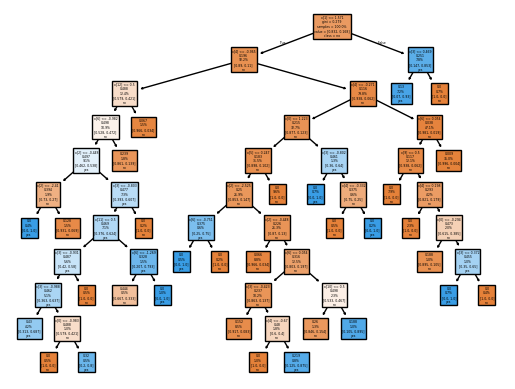

Beslisboom met alpha = 0.001794, AUC = 0.930

In [9]:
plot_tree(gridsearch.best_estimator_.named_steps['model'],
            class_names = ['no', 'yes'],
            filled = True,
            proportion=True,
            label = 'root')
plt.show()
Markdown(f'Beslisboom met alpha = {best_alpha:.6f}, AUC = {best_score:.3f}')

Class,Precision,Recall,F1-score,Support
Niet Opgezegd,0.98,0.97,0.98,1660
Opgezegd,0.88,0.88,0.88,335

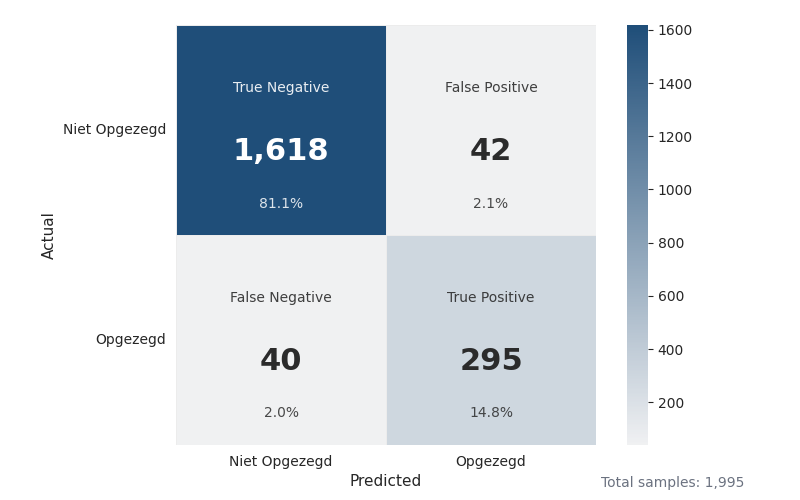

In [10]:
class_names = ["Niet Opgezegd", "Opgezegd"]
y_pred = gridsearch.predict(X)

display_executive_model_evaluation(
    y,
    y_pred,
    class_names=class_names
)

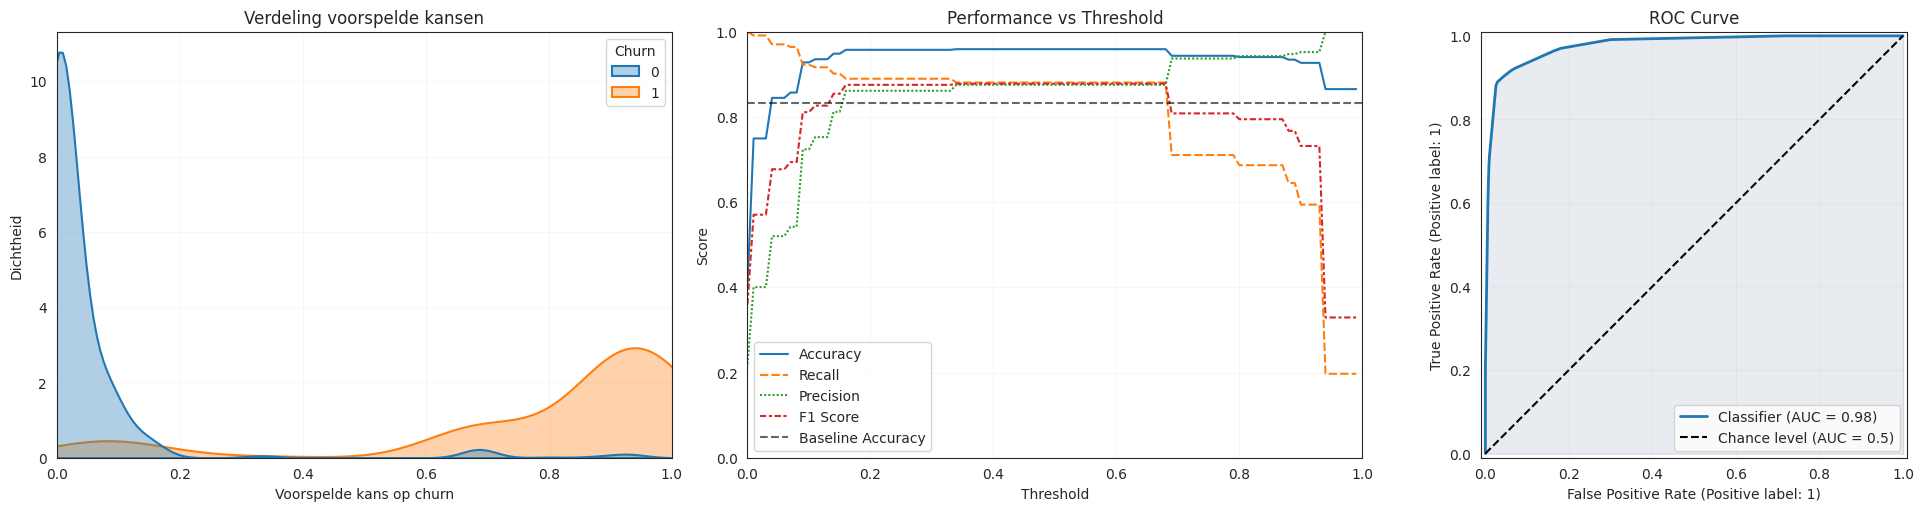

In [11]:
# 3 beschrijvende figuren
y_prob = gridsearch.predict_proba(X)[:,1] 
evaluate_classification_model(y, y_prob, X, df)

### 5. Keuze van modelcomplexiteit (α)

Hoewel `GridSearchCV` de waarde van `ccp_alpha` bepaalt met de hoogste **ROC-AUC**, 
wordt deze niet direct gekozen.

Op basis van de α-plot wordt een iets hogere waarde gekozen in het gebied waar de prestaties stabiel blijven (plateau).  
Hierdoor wordt de boom eenvoudiger, terwijl de prestaties vrijwel gelijk blijven.

De gekozen waarde is:
- `ccp_alpha = 0.0022`

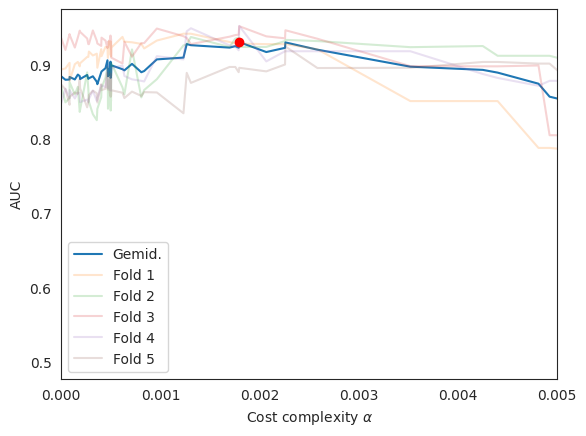

In [12]:
sns.lineplot(gridsearch.cv_results_, x = 'param_model__ccp_alpha', y = 'mean_test_score', label = 'Gemid.')
for i in range(5):
    sns.lineplot(gridsearch.cv_results_, 
                 x = 'param_model__ccp_alpha', 
                 y = f'split{i}_test_score', 
                 alpha = 0.2, 
                 label = f'Fold {i+1}')
plt.plot(best_alpha, best_score, 'ro')
plt.xlim(0, 0.005)
plt.xlabel('Cost complexity $\\alpha$')
plt.ylabel('AUC')
plt.show()

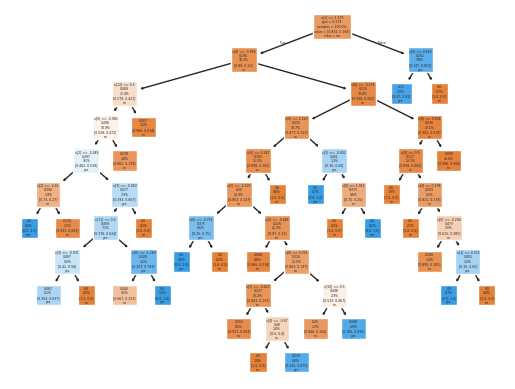

In [13]:
beslisboom_pipe.set_params(model__ccp_alpha = 0.0022)
pruned_tree = beslisboom_pipe.fit(X, y)
plot_tree(pruned_tree.named_steps['model'],
            class_names = ['no', 'yes'],
            filled = True,
            proportion=True,
            label = 'root')
plt.show()

Class,Precision,Recall,F1-score,Support
Niet Opgezegd,0.98,0.97,0.97,1660
Opgezegd,0.85,0.88,0.87,335

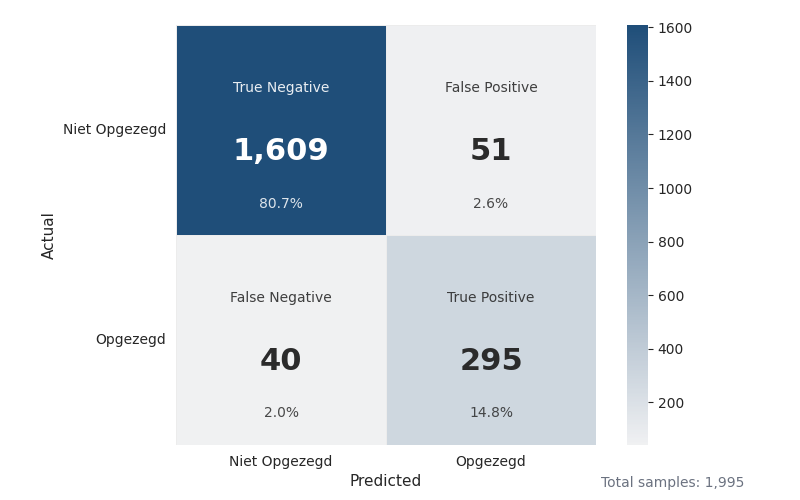

In [14]:
class_names = ["Niet Opgezegd", "Opgezegd"]
y_pred = pruned_tree.predict(X)

display_executive_model_evaluation(
    y,
    y_pred,
    class_names=class_names
)

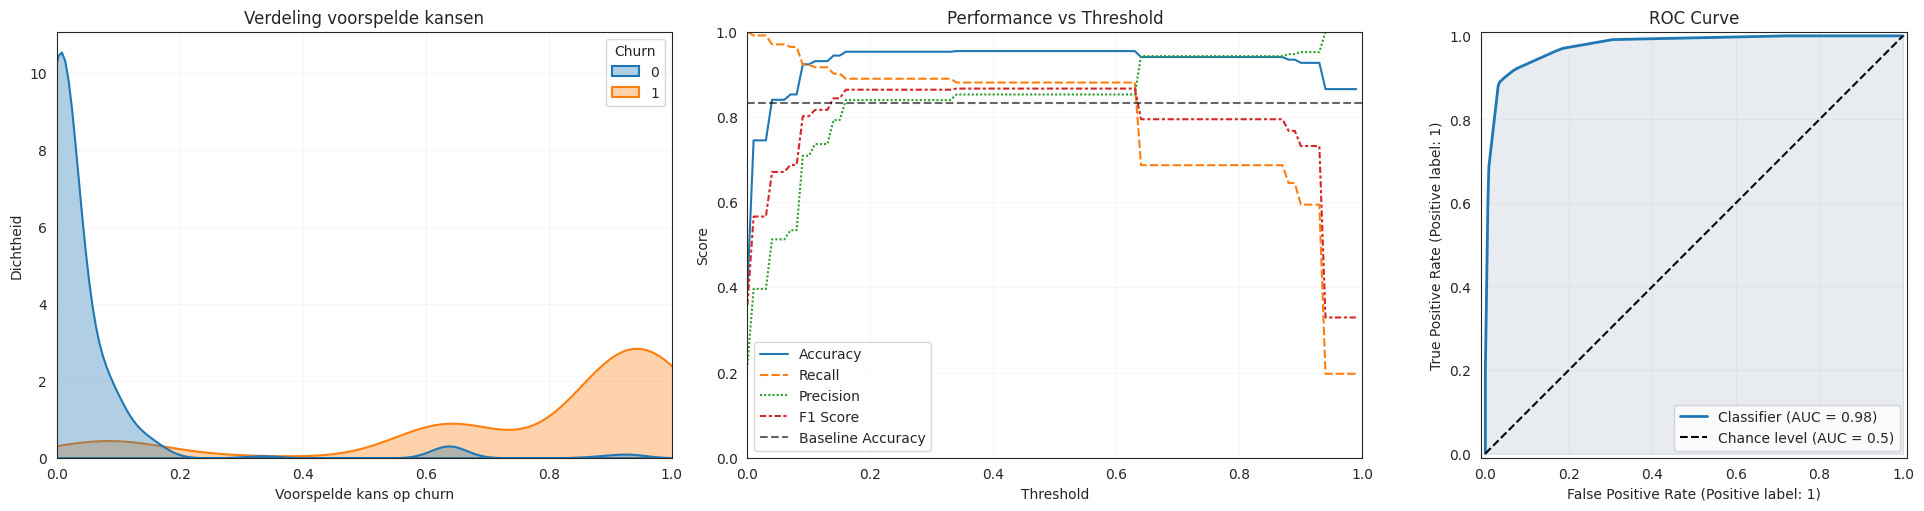

In [15]:
# 3 beschrijvende figuren
y_prob = pruned_tree.predict_proba(X)[:,1] 

evaluate_classification_model(y, y_prob, X, df)

### 6. Model opslaan

De beste pipeline (inclusief preprocessing en model) wordt opgeslagen in een `.joblib` bestand met `joblib.dump()`.  
Hierdoor kan het model later opnieuw worden geladen zonder het opnieuw te trainen.

In [16]:
# De pipeline opslaan als bestand
joblib.dump(pruned_tree, "beslisboom_pipe.joblib")
# Model weer inladen:
# beslisboom_pipe = joblib.load("beslisboom_pipe.joblib")

['beslisboom_pipe.joblib']

### 7. Beslissingsstrategie & winstanalyse

Voor elke klant wordt een **gepersonaliseerde threshold** berekend op basis van verwachte winst van twee tarieven.  

- **Tarief 2** wordt aangeboden als churn-kans boven de threshold ligt.  
- De verwachte maandelijkse winst wordt berekend en vergeleken met de maximale haalbare winst, zodat de effectiviteit van het model wordt beoordeeld.

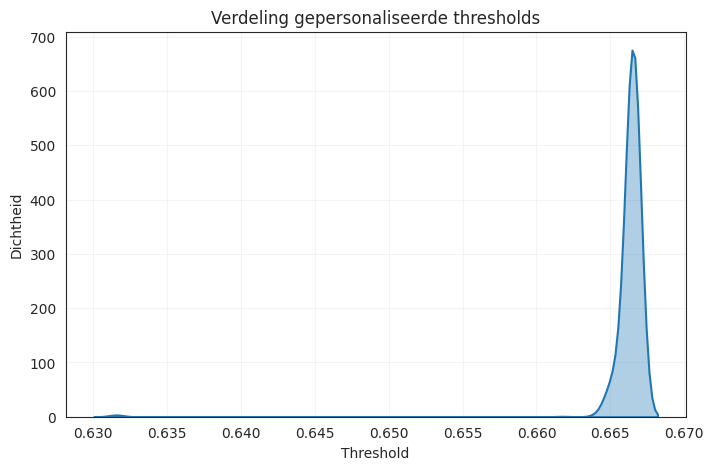

Aantal klanten tarief 2: 237
Totaal aantal klanten: 1995
Percentage tarief 2: 11.88%


In [17]:
y_prob = pruned_tree.predict_proba(X)[:, 1]
# Winst per tarief
W1 = 0.1 * X["Frequency of SMS"] + 0.3 * X["Seconds of Use"]
W2 = 0.07 * X["Frequency of SMS"] + 0.2 * X["Seconds of Use"]

# Balansvergelijking
df["thresholds"] = (W1 - W2) / (W1 - 0.75 * W2)

# Beslissing
offer_tarief2 = (y_prob >= df["thresholds"])

# Visualisatie
plt.figure(figsize=(8,5))
sns.kdeplot(df["thresholds"], fill=True, alpha=0.35, linewidth=1.5)
plt.title("Verdeling gepersonaliseerde thresholds")
plt.xlabel("Threshold")
plt.ylabel("Dichtheid")
plt.grid(alpha=0.2)
plt.show()

# Samenvatting
n_tarief2 = offer_tarief2.sum()

print(f"Aantal klanten tarief 2: {n_tarief2}")
print(f"Totaal aantal klanten: {len(df)}")
print(f"Percentage tarief 2: {n_tarief2/len(df):.2%}")

In [18]:
# Winst omzetten naar per maand
sms_pm = X["Frequency of SMS"] / 9
min_pm = (X["Seconds of Use"] / 60) / 9

W1_pm = 0.1 * sms_pm + 0.3 * min_pm
W2_pm = 0.07 * sms_pm + 0.2 * min_pm

# Verwachte winst per klant per maand
E_tarief1_model = (1 - y_prob) * W1_pm
E_tarief2_model = (1 - 0.75 * y_prob) * W2_pm

# Totale verwachte winst
totale_winst_model = E_tarief2_model[offer_tarief2 == 1].sum() + E_tarief1_model[offer_tarief2 == 0].sum()

# maximum winst per klant per maand
E_tarief1_max = (1 - y) * W1_pm
E_tarief2_max = (1 - 0.75 * y) * W2_pm

# Totale maximum winst 
totale_winst_max = E_tarief2_max[y == 1].sum() + E_tarief1_max[y == 0].sum()

# Berekeningen
verschil_winst = totale_winst_max - totale_winst_model
n_tarief2 = offer_tarief2.sum()
n_tarief2_optimaal = y.sum()
verschil_klanten = n_tarief2 - n_tarief2_optimaal
perc_tarief2 = n_tarief2 / len(X)
perc_tarief2_optimaal = n_tarief2_optimaal / len(X)

if verschil_klanten > 0:
    interpretatie = f"Het model biedt {verschil_klanten} klanten te veel tarief 2 aan (te agressief)."
elif verschil_klanten < 0:
    interpretatie = f"Het model biedt {-verschil_klanten} klanten te weinig tarief 2 aan (te voorzichtig)."
else:
    interpretatie = "Het model biedt precies het optimale aantal klanten tarief 2 aan."

interpretatie += f" Het model behaalt {totale_winst_model/totale_winst_max:.2%} van de maximale winst"
interpretatie += f" met een vershil van €{verschil_winst:.2f}."

# Progress bar voor percentage van maximale winst
pct_winst = totale_winst_model / totale_winst_max
bar_len = 30
filled_len = int(bar_len * pct_winst)
bar = '█' * filled_len + '-' * (bar_len - filled_len)

# Markdown tabel
table_md = f"""
### Resultaten & Strategie

| Strategie | Tarief 2 (# klanten / %) | Winst per maand (€) |
|-----------|------------------------|------------------|
| Optimaal  | {int(n_tarief2_optimaal)} ({perc_tarief2_optimaal:.2%}) | {totale_winst_max:.2f} |
| Model     | {n_tarief2} ({perc_tarief2:.2%}) | {totale_winst_model:.2f} |

**Interpretatie:** {interpretatie}  
**Verschil klanten Tarief 2:** {verschil_klanten:+}  
**Winstverschil:** €{verschil_winst:.2f}  

**Percentage van maximale winst behaald:**  
`{bar}` {pct_winst:.2%}
"""


display(Markdown(table_md))


### Resultaten & Strategie

| Strategie | Tarief 2 (# klanten / %) | Winst per maand (€) |
|-----------|------------------------|------------------|
| Optimaal  | 335 (16.79%) | 6270.30 |
| Model     | 237 (11.88%) | 6242.22 |

**Interpretatie:** Het model biedt 98 klanten te weinig tarief 2 aan (te voorzichtig). Het model behaalt 99.55% van de maximale winst met een vershil van €28.08.  
**Verschil klanten Tarief 2:** -98  
**Winstverschil:** €28.08  

**Percentage van maximale winst behaald:**  
`█████████████████████████████-` 99.55%
